In [16]:
from utils import *
fix_seed(2020) # 这个种子到底怎么设比较好
path = "../Data/1.DLPFC/151507/"
adata = preprocess(path)
label = pd.read_table(path + "/metadata.tsv")
adata.obs["ground_truth"] = label["layer_guess_reordered"].values
valid = ~pd.isnull(label["layer_guess_reordered"])  # 去空值
adata=adata[valid].copy()
adata.shape

d:\study\project\HGM\utils.py:27: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path, count_file="filtered_feature_bc_matrix.h5")
e:\Miniconda3\envs\hgm\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
e:\Miniconda3\envs\hgm\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


preprocess done, adata.shape: (4226, 3000)


(4221, 3000)

In [17]:
shg,fhg=KnnHyperGraph(adata)

空间超图构建完成: |V|=4221, |E|=4221, k=8
特征超图构建完成: |V|=4221, |E|=4221, k=8


100%|██████████| 100/100 [00:04<00:00, 22.88it/s]


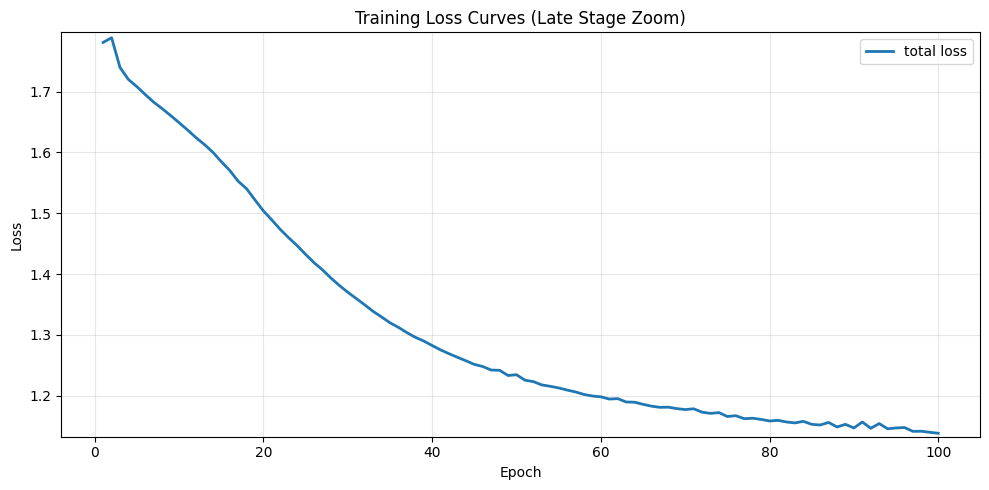

In [18]:
import torch
import torch.nn.functional as F
from model import HGM

# 预处理后的高变基因表达矩阵作为节点特征 (N, 3000)
features = torch.tensor(adata.X.toarray(), dtype=torch.float32)
model = HGM(in_dim=features.shape[1], hid_dim=128, out_dim=32, proj_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
if torch.cuda.is_available():
    model = model.cuda()
    features = features.cuda()
    shg = shg.to(device='cuda')
    fhg = fhg.to(device='cuda')

epochs = 100
alpha = 1.0
beta = 0.1
temperature = 0.2

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

loss_history = []
loss_re_history = []
loss_con_history = []

for epoch in tqdm(range(1, epochs + 1)):
    model.train()
    optimizer.zero_grad()
    z, zs, zf, x_hat = model(features, shg, fhg)
    loss_re = F.mse_loss(x_hat, features)  # 重建损失
    loss_con = infoNCE(zs, zf, temperature=temperature)  # 对比损失
    loss = alpha * loss_re + beta * loss_con
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    loss_re_history.append(loss_re.item())
    loss_con_history.append(loss_con.item())

# 显示 total / reconstruction / contrastive 三种损失的后期收敛曲线
plot_start = max(0, len(loss_history) - 100)
epochs_range = range(plot_start + 1, epochs + 1)
plot_total_losses = loss_history[plot_start:]
# plot_re_losses = loss_re_history[plot_start:]
# plot_con_losses = loss_con_history[plot_start:]

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, plot_total_losses, label='total loss', linewidth=2, color='tab:blue')
# plt.plot(epochs_range, plot_re_losses, label='reconstruction loss', linewidth=2, color='tab:green')
# plt.plot(epochs_range, plot_con_losses, label='contrastive loss', linewidth=2, color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves (Late Stage Zoom)')
plt.legend()
plt.grid(alpha=0.3)

# all_plot_losses = plot_total_losses + plot_re_losses + plot_con_losses
all_plot_losses = plot_total_losses
if all_plot_losses:
    y_min = min(all_plot_losses)
    y_max = max(all_plot_losses)
    if y_max > y_min:
        plt.ylim(y_min * 0.995, y_max * 1.005)

plt.tight_layout()
plt.show()

In [19]:
model.eval()
with torch.no_grad():
    z, _, _, _ = model(features, shg, fhg)

from sklearn.decomposition import PCA
z = z.detach().cpu().numpy()
pca = PCA(n_components=20)
z = pca.fit_transform(z)
# adata=adata[valid].copy()
# z = z[valid]

In [20]:
cluster_df, res_df = cluster_score(adata, z, pca=True)
print("\n聚类方法评估结果:")
print(res_df.round(4))

fitting ...
  |======================================================================| 100%

聚类方法评估结果:
           ARI     NMI     FMI
mclust  0.4966  0.6709  0.5942
